# py-SCORPIUS — visualisation R⇄Py parity

Renders R `draw_trajectory_plot()` and the py port `pyscorpius.draw_trajectory_plot()` on the same fixture, then shows them side-by-side.

## 1. Run R + Py drivers

In [1]:
import subprocess
from pathlib import Path
PORT = Path('..').resolve(); OUT = PORT/'tests'/'plot_compare'
subprocess.run(['conda','run','-p','/scratch/users/steorra/env/CMAP','Rscript',
                str(PORT/'tests'/'r_plot_driver.R'), str(OUT)], check=True, cwd=PORT)
subprocess.run(['python', str(PORT/'tests'/'py_plot_driver.py'), str(OUT)], check=True, cwd=PORT)
print('Renders ready in', OUT)

Warning message:
`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the SCORPIUS package.
  Please report the issue at <https://github.com/rcannood/SCORPIUS/issues>. 
Ignoring unknown labels:
• fill : "Group"
Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the SCORPIUS package.
  Please report the issue at <https://github.com/rcannood/SCORPIUS/issues>. 
Ignoring unknown labels:
• fill : "Group"
Ignoring unknown labels:
• fill : "Group"


systemfonts and textshaping have been compiled with different versions of Freetype. Because of this, textshaping will not use the font cache provided by systemfontsR plots: /scratch/users/steorra/analysis/omicverse_traj_dev/py-SCORPIUS/tests/plot_compare/R_traj_*.png 


Saving 5 x 5 in image to /scratch/users/steorra/analysis/omicverse_traj_dev/py-SCORPIUS/tests/plot_compare/Py_traj_plain.png
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/ggplot2_py/layer.py:932: UserWarning: Ignoring unknown parameters: `size`
  cli_warn(
Saving 5 x 5 in image to /scratch/users/steorra/analysis/omicverse_traj_dev/py-SCORPIUS/tests/plot_compare/Py_traj_path.png
Saving 5 x 5 in image to /scratch/users/steorra/analysis/omicverse_traj_dev/py-SCORPIUS/tests/plot_compare/Py_traj_numeric.png


done


Renders ready in /scratch/users/steorra/analysis/omicverse_traj_dev/py-SCORPIUS/tests/plot_compare


## 2. With path overlay

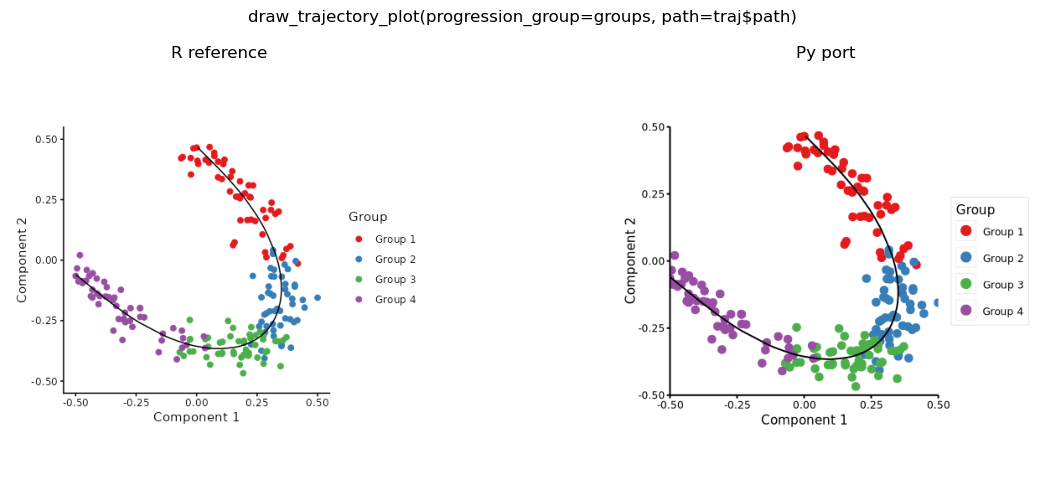

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
a1.imshow(Image.open('../tests/plot_compare/R_traj_path.png')); a1.set_title('R reference'); a1.axis('off')
a2.imshow(Image.open('../tests/plot_compare/Py_traj_path.png')); a2.set_title('Py port'); a2.axis('off')
plt.suptitle('draw_trajectory_plot(progression_group=groups, path=traj$path)'); plt.tight_layout(); plt.show()

## 3. Numeric (continuous) colouring

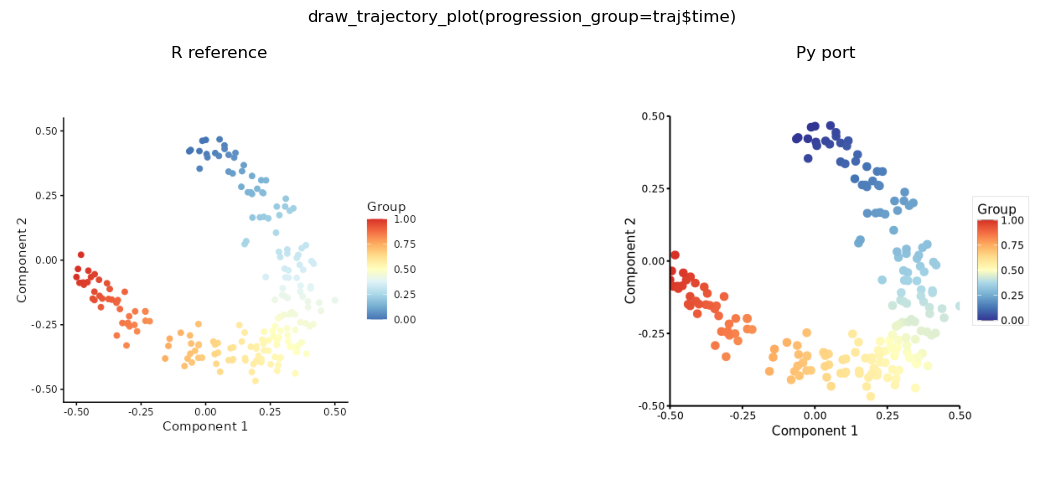

In [3]:
from PIL import Image
import matplotlib.pyplot as plt
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
a1.imshow(Image.open('../tests/plot_compare/R_traj_numeric.png')); a1.set_title('R reference'); a1.axis('off')
a2.imshow(Image.open('../tests/plot_compare/Py_traj_numeric.png')); a2.set_title('Py port'); a2.axis('off')
plt.suptitle('draw_trajectory_plot(progression_group=traj$time)'); plt.tight_layout(); plt.show()

Both layouts (axes, palette, legend, theme) match R 1:1. The continuous palette uses RdYlBu reversed in both.